In [1]:
#!pip install xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score, recall_score, fbeta_score,
    precision_recall_curve, auc, classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import joblib


In [3]:
df = pd.read_csv("modeling_dataset_v1.csv")

X = df.drop(columns=['company_id', 'financial_year_end', 'label'])
y = df['label']
years = df['financial_year_end']

print("Dataset shape:", df.shape)


Dataset shape: (401, 23)


In [4]:
train_mask = years <= 2020
val_mask = (years >= 2021) & (years <= 2023)
test_mask = years >= 2024

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("=== DATA SPLIT SUMMARY ===")
print(f"Train (≤2020): {len(X_train)}")
print(f"Validation (2021–2023): {len(X_val)}")
print(f"Test (≥2024): {len(X_test)}")


=== DATA SPLIT SUMMARY ===
Train (≤2020): 122
Validation (2021–2023): 208
Test (≥2024): 71


In [5]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost training completed")

XGBoost training completed


In [6]:
y_val_pred = xgb_model.predict(X_val)
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

val_precision = precision_score(y_val, y_val_pred, pos_label=1)
val_recall = recall_score(y_val, y_val_pred, pos_label=1)
val_f2 = fbeta_score(y_val, y_val_pred, beta=2, pos_label=1)

p, r, _ = precision_recall_curve(y_val, y_val_proba)
val_pr_auc = auc(r, p)

print("=== VALIDATION PERFORMANCE (2021–2023) ===")
print(f"Recall:    {val_recall:.3f}")
print(f"Precision: {val_precision:.3f}")
print(f"F2-score:  {val_f2:.3f}")
print(f"PR-AUC:    {val_pr_auc:.3f}")

=== VALIDATION PERFORMANCE (2021–2023) ===
Recall:    1.000
Precision: 0.692
F2-score:  0.918
PR-AUC:    0.908


In [7]:
y_test_pred = xgb_model.predict(X_test)
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2, pos_label=1)

p, r, _ = precision_recall_curve(y_test, y_test_proba)
test_pr_auc = auc(r, p)

print("=== TEST SET PERFORMANCE (≥ 2024) ===")
print(f"Recall:    {test_recall:.3f}")
print(f"Precision: {test_precision:.3f}")
print(f"F2-score:  {test_f2:.3f}")
print(f"PR-AUC:    {test_pr_auc:.3f}")

=== TEST SET PERFORMANCE (≥ 2024) ===
Recall:    1.000
Precision: 0.750
F2-score:  0.938
PR-AUC:    0.866


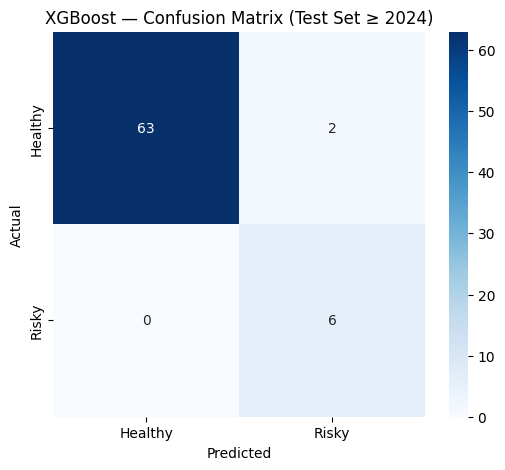

In [8]:
THRESHOLD = 0.23
y_test_pred_thr = (y_test_proba >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_test_pred_thr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Risky"],
    yticklabels=["Healthy", "Risky"]
)

plt.title("XGBoost — Confusion Matrix (Test Set ≥ 2024)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [9]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

In [10]:
print(feature_importance)

                       feature  importance
17      pct_years_ocf_negative    0.275786
0        operating_cf_3yr_mean    0.117804
13   total_liabilities_3yr_std    0.094169
16  financing_dependency_ratio    0.092474
4        financing_cf_3yr_mean    0.080739
5         financing_cf_3yr_std    0.065681
11        total_assets_3yr_std    0.052022
2        investing_cf_3yr_mean    0.044755
1         operating_cf_3yr_std    0.044174
3         investing_cf_3yr_std    0.040554
10       total_assets_3yr_mean    0.015910
15              equity_3yr_std    0.013715
8    profit_after_tax_3yr_mean    0.012473
18          revenue_3yr_growth    0.012433
12  total_liabilities_3yr_mean    0.011108
6             revenue_3yr_mean    0.010137
9     profit_after_tax_3yr_std    0.006761
7              revenue_3yr_std    0.006065
14             equity_3yr_mean    0.003239
19           profit_3yr_growth    0.000000


In [11]:
test_predictions_xgb = pd.DataFrame({
    'company_id': df.loc[y_test.index, 'company_id'],
    'financial_year_end': df.loc[y_test.index, 'financial_year_end'],
    'true_label': y_test.values,
    'xgb_pred': y_test_pred,
    'xgb_pred_proba': y_test_proba
})

test_predictions_xgb.to_csv("xgboost_test_predictions_2024_plus.csv", index=False)

print("Saved XGBoost test predictions")


Saved XGBoost test predictions


In [12]:
joblib.dump(xgb_model, "xgboost_model.joblib")

['xgboost_model.joblib']

In [14]:
FEATURE_COLUMNS = list(X_train.columns)

joblib.dump(FEATURE_COLUMNS, "feature_columns.joblib")

['feature_columns.joblib']

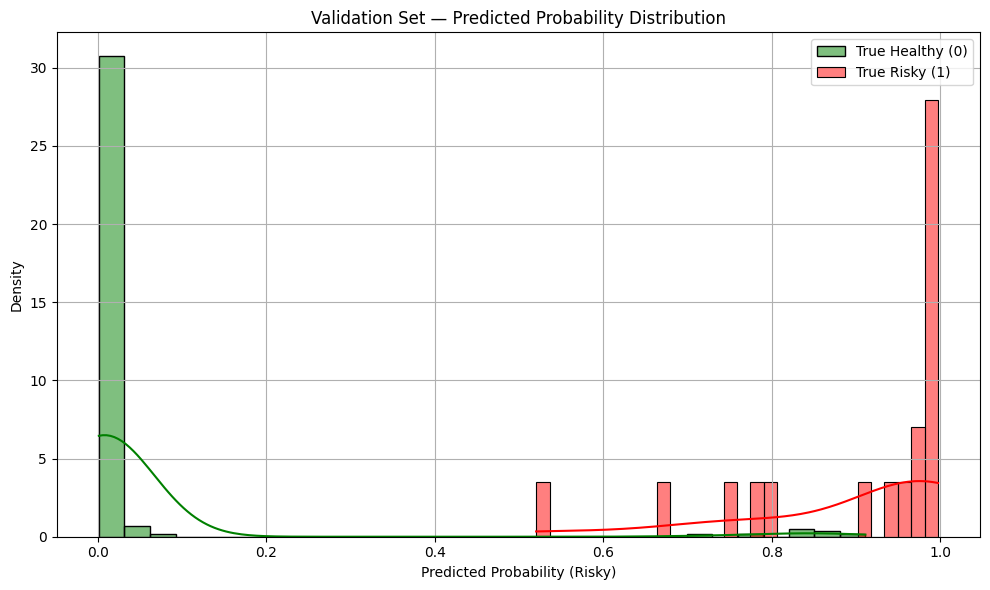

In [13]:
# Split probabilities by TRUE label
val_probs_risky = y_val_proba[y_val == 1]
val_probs_healthy = y_val_proba[y_val == 0]

plt.figure(figsize=(10, 6))

# Histogram + KDE for Healthy
sns.histplot(
    val_probs_healthy,
    bins=30,
    kde=True,
    stat="density",
    color="green",
    alpha=0.5,
    label="True Healthy (0)"
)

# Histogram + KDE for Risky
sns.histplot(
    val_probs_risky,
    bins=30,
    kde=True,
    stat="density",
    color="red",
    alpha=0.5,
    label="True Risky (1)"
)

plt.xlabel("Predicted Probability (Risky)")
plt.ylabel("Density")
plt.title("Validation Set — Predicted Probability Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
